In [1]:
using NacreDualDamage

In [2]:
?NacreDualDamage.solve_nacre_model

```julia
solve_nacre_model(; kwargs...) -> Dict
```

Execute a complete phase-field fracture simulation on a nacre RVE with dual damage fields.

This function orchestrates the entire simulation workflow:

1. Load geometry and setup periodic boundary conditions
2. Initialize displacement and damage fields
3. Execute staggered Newton-Raphson solution for each load step
4. Save visualization (VTK) and binary (JLD2) outputs
5. Return complete simulation history

# Simulation Algorithm

The solver employs a staggered scheme at each load increment:

```julia
for each load step:
    1. Apply boundary conditions (prescribed strain εₘ)
    2. Solve for displacement u with damage d fixed
    3. Solve for damage d_tablets with u fixed
    4. Solve for damage d_matrix with u fixed
    5. Final displacement update
    6. Store results and check convergence
```

Damage irreversibility is enforced via KKT conditions: dⁿ⁺¹ ≥ dⁿ

# Keyword Arguments

## Model Definition

  * `sModelName::String`: Base name of mesh file (default: "platelets_tet1x1x1L1000w0100t0200rp500lct200lcm0250")
  * `θ, ψ, ζ::Float64`: Euler angles for RVE rotation (default: 0.0)

## Material Properties

  * `matrix_mat::PhaseField`: Matrix phase-field material (default: AT2 neo-Hookean)

      * Default: E=4 GPa, ν=0.27, εc=2.5%, l₀=0.01 μm, n=2
  * `tablets_mat::PhaseField`: Tablet phase-field material (default: AT1 Hookean)

      * Default: E=100 GPa, ν=0.27, εc=0.5%, l₀=0.01 μm, n=1

## Loading

  * `εM0::Vector`: Applied macroscopic strain [ε₁₁, ε₂₂, ε₃₃, ε₂₃, ε₁₃, ε₁₂] (default: [0.05, NaN, NaN, NaN, NaN, NaN])

      * Use `NaN` for free components (stress-controlled)
      * Use scalar values for constrained components (strain-controlled)

## Solution Control

  * `nSteps::Int`: Number of load increments (default: 200)
  * `maxiter::Int`: Maximum global staggered iterations (default: 4)

### Displacement Solver

  * `miniteru::Int`: Minimum displacement iterations (default: 1)
  * `maxiteru::Int`: Maximum displacement iterations (default: 7)
  * `dTolrnorm::Float64`: Residual norm convergence ratio (default: 1.5)
  * `dTolu::Float64`: Displacement residual tolerance (default: 5e-6)

### Damage Solver

  * `maxiterd::Int`: Maximum damage iterations (default: 1)
  * `dTold::Float64`: Damage residual tolerance (default: 1e-6)

## Numerical Parameters

  * `λT::Float64`: Mass matrix stabilization parameter (default: 1e-2)
  * `busePardiso::Bool`: Use PARDISO sparse direct solver (default: true)

## I/O Control

  * `sPath::String`: Working directory (default: pwd())
  * `sModelPath::String`: Input mesh directory (default: joinpath(sPath, "mesh_files"))
  * `sJLD2Path::String`: Binary output directory (default: joinpath(sPath, "jld2_files"))
  * `svtkPath::String`: VTK output directory (default: joinpath(sPath, "vtk_files"))
  * `iSaveVTK::Int`: VTK output frequency in steps (default: nSteps÷10)
  * `iSavejld2::Int`: JLD2 output frequency (default: iSaveVTK)
  * `sPost::String`: Filename postfix (default: "")

# Returns

Dictionary containing complete simulation results:

  * `"εM"`: Macroscopic strain history [6 × nSteps]
  * `"σM"`: Macroscopic stress history [6 × nSteps]
  * `"Vd"`: Volume-averaged damage fractions (tablets, matrix) [2 × nSteps]
  * `"steps"`: Saved field snapshots [{iStep, u, d}...]
  * `"Vol"`: RVE volumes (tablets, matrix)
  * `"θ", "ψ", "ζ"`: Rotation angles
  * `"ai"`: Periodic lattice vectors
  * `"matrix_mat"`, `"tablets_mat"`: Material definitions
  * `"datestart"`: Simulation start timestamp

# Example Usage

```julia
using NacreDualDamage

# Apply 2% strain in the y-direction (component 2 in Voigt notation)
ϵM0 = [NaN, 0.02, NaN, NaN, NaN, NaN];
sPost = "NaNe22NaNt";
results = solve_nacre_model(
    sModelName = "nacre_tet1x1x1L0300w0050t0050rp060lc0300",
    ϵM0        = ϵM0,
    nSteps     = 100,
    sPath      = pwd(),
    sPost      = sPost
);

println(keys(results)

# Extract stress-strain curve
ϵ22 = results["ϵM"][2, :];  # Strain in direction 22
σ22 = results["σM"][2, :];  # Stress in direction 22

# Plot the results
using Plots
plot(ϵ22, σ22, xlabel="Strain ε₂₂", ylabel="Stress σ₂₂ (MPa)", 
     title="Uniaxial Tensile Response", linewidth=2, grid=true )
```

# Notes

## Mesh Requirements

Input mesh must contain:

  * Node sets: "left", "right", "bottom", "top", "front", "back" (for periodicity)
  * Node sets: "matrix", "tablets" (for material assignment)
  * Element sets: "matrix", "tablets"

## Convergence Behavior

  * Displacement solver uses Newton-Raphson with adaptive tangent updates
  * Damage solver enforces irreversibility via active set method
  * Simulation terminates on convergence failure (state saved for recovery)

## Parallel Performance

Element assembly is parallelized via `Threads.@threads`. Set `JULIA_NUM_THREADS`  environment variable before launching Julia for optimal performance.


In [3]:
# Apply 2% strain in the y-direction (component 2 in Voigt notation)
ϵM0 = [NaN, 0.02, NaN, NaN, NaN, NaN]
sPost = "NaNe22NaNt"
results = solve_nacre_model(
            sModelName = "nacre_tet1x1x1L0300w0050t0050rp060lc0300",
            ϵM0        = ϵM0,
            nSteps     = 100,
            sPath      = pwd(),
            sPost      = sPost
        )

println(keys(results)

# Extract stress-strain curve
ϵ22 = results["ϵM"][2, :]  # Strain in direction 22
σ22 = results["σM"][2, :]  # Stress in direction 22
;

Commencing simulation: 
	nacre_tet1x1x1L0300w0050t0050rp060lc0300NaNe22NaNt

Start time: 2026-01-29T17:45:03.239 

ϵM0 = [NaN, 0.02, NaN, NaN, NaN, NaN]
Writing animation to 
	/home/andrea/METMAT/layered_materials/layered_materials_240701/nacre-dual-damage/examples/vtk_files/nacre_tet1x1x1L0300w0050t0050rp060lc0300NaNe22NaNt.pvd

Loading model and setting up periodic boundary conditions...


 Rotation matrix:
  | 1.000,  0.000,  0.000|
  | 0.000,  1.000,  0.000|
  | 0.000,  0.000,  1.000|

 constructing elements ...  done in 1.15 sec. 

typeof(tablts_elems) = Vector{AD4SM.Elements.C3DP}
length(tablts_elems) = 5935
typeof(matrix_elems) = Vector{AD4SM.Elements.C3DP}
length(matrix_elems) = 4876
 ... done

Matrix material properties:
AD4SM.Materials.PhaseField{AD4SM.Materials.NeoHooke{Float64}, :ATn}
  l0: Float64 0.01
  Gc: Float64 7.500000000000001e-5
  mat: AD4SM.Materials.NeoHooke{Float64}
    C1: Float64 0.7874015748031495
    K: Float64 0.924340979116741
    ρ: Float64 1.0
    small:

┌ Warning: Simulation error:
│ Zero pivot, numerical fact. or iterative refinement problem.
│ 14-element Vector{Base.StackTraces.StackFrame}:
│  check_error(ps::Pardiso.MKLPardisoSolver, err::Int32) at mkl_pardiso.jl:83
│  ccall_pardiso(ps::Pardiso.MKLPardisoSolver, N::Int64, nzval::Vector{Float64}, colptr::Vector{Int64}, rowval::Vector{Int64}, NRHS::Int64, B::Vector{Float64}, X::Vector{Float64}) at mkl_pardiso.jl:75
│  pardiso(ps::Pardiso.MKLPardisoSolver, X::Vector{Float64}, A::SparseArrays.SparseMatrixCSC{Float64, Int64}, B::Vector{Float64}) at Pardiso.jl:510
│  pardiso at Pardiso.jl:515 [inlined]
│  updtu!(ps::Pardiso.MKLPardisoSolver, u1::Vector{Float64}, elems::Tuple{Vector{AD4SM.Elements.C3DP}, Vector{AD4SM.Elements.C3DP}}, u::Matrix{Float64}, d::Tuple{Matrix{Float64}, Matrix{Float64}}, ru::Matrix{Float64}, BB1::SparseArrays.SparseMatrixCSC{Float64, Int64}, MM::SparseArrays.SparseMatrixCSC{Float64, Int64}, λT::Float64, ifree::Vector{Int64}, maxiter::Int64; dTolu::Float64, maxnor

Quitting.

State written to: 
	/home/andrea/METMAT/layered_materials/layered_materials_240701/nacre-dual-damage/examples/vtk_files/nacre_tet1x1x1L0300w0050t0050rp060lc0300NaNe22NaNt_043.vtm

Animation written to 
	/home/andrea/METMAT/layered_materials/layered_materials_240701/nacre-dual-damage/examples/vtk_files/nacre_tet1x1x1L0300w0050t0050rp060lc0300NaNe22NaNt.pvd

Saving binary data to 
	/home/andrea/METMAT/layered_materials/layered_materials_240701/nacre-dual-damage/examples/jld2_files/nacre_tet1x1x1L0300w0050t0050rp060lc0300NaNe22NaNt.jld2 ...
  3.341277 seconds (5.03 M allocations: 248.085 MiB, 1.25% gc time, 95.01% compilation time: 15% of which was recompilation)

Finished on 2026-01-29T17:48:47.828, Total execution time: 00:03:45


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///home/andrea/METMAT/layered_materials/layered_materials_240701/nacre-dual-damage/examples/In[3]#12:22\[90mIn[3]:12:22[0;0m]8;;\

println(keys(results)[48;2;120;70;70m[0;0m
[90m#                    └ ── [0;0m[91mExpected `)` or `,`[0;0m

In [8]:
println(keys(results))
;

["steps", "Vol", "tablets_mat", "sModelName", "ζ", "matrix_mat", "ϵM0", "sPost", "ϵM", "σM", "nSteps", "ψ", "datestart", "Vd", "iStep", "sFileName", "θ", "ai"]


In [9]:
print(keys(results["steps"][1]))

["iStep", "u", "d"]

In [10]:
results["ϵM"]

6×43 Matrix{Float64}:
 0.0  -5.16709e-5  -0.000103061  -0.000153807  …   0.000268175   0.000354113
 0.0   0.0002       0.0004        0.0006           0.0082        0.0084
 0.0  -4.72601e-5  -9.41349e-5   -0.000140137     -0.000123642  -0.000115883
 0.0  -1.02338e-8  -2.16711e-8   -3.36794e-8       2.9455e-6     2.89337e-6
 0.0  -3.49658e-8  -7.27354e-8   -1.1633e-7       -1.41678e-5   -4.11221e-5
 0.0   2.14376e-8   4.5848e-8     7.22856e-8   …  -0.000157363   3.72195e-5

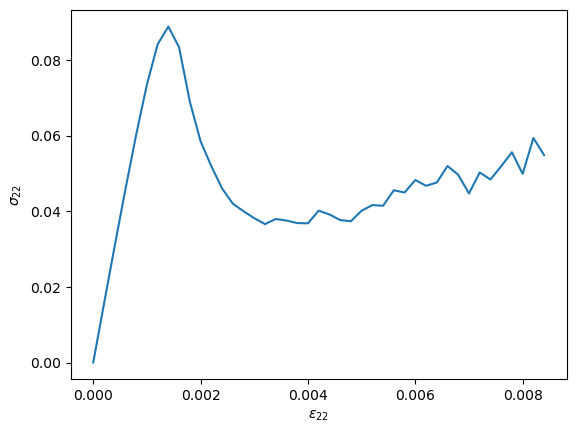

In [12]:
using PyPlot

ax = plt.subplot()
ax.plot(results["ϵM"][2,:], results["σM"][2,:])
ax.set_xlabel("\$\\epsilon_{22}\$")
ax.set_ylabel("\$\\sigma_{22}\$")
;